# Assignment2_2

In [1]:
# peak of training data
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(root = './data', train = True, download = True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

_img, _label = train_dataset[0]
print(_img.shape)

torch.Size([3, 32, 32])


In [2]:
print(train_dataset.class_to_idx)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


Current directory: D:\Columbia\Summer2026\5560_applied_ai\assignment2
Data directory: D:\Columbia\Summer2026\5560_applied_ai\assignment2\data
Output directory: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images
Dataset size: 10000
Saved: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images\1_truck_1824.png
Saved: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images\2_bird_409.png
Saved: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images\3_automobile_4506.png
Saved: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images\4_cat_4012.png
Saved: D:\Columbia\Summer2026\5560_applied_ai\assignment2\sample_images\5_horse_3657.png


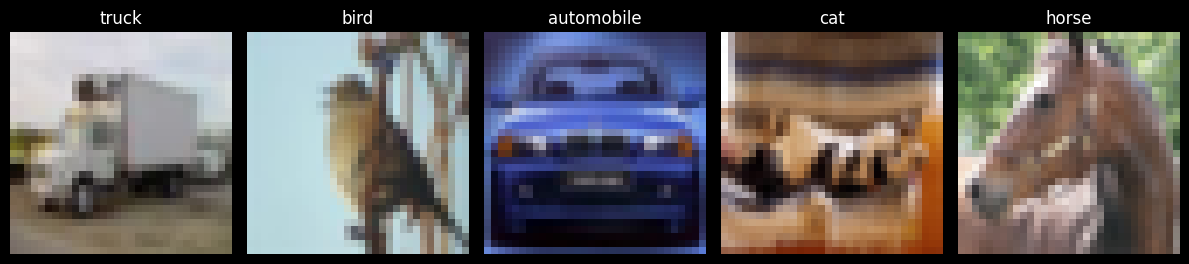

In [3]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
from torchvision import datasets


CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "sample_images"

OUTPUT_DIR.mkdir(exist_ok=True)

print("Current directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Output directory:", OUTPUT_DIR)


dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=None
)

print("Dataset size:", len(dataset))


random.seed(42)
indices = random.sample(range(len(dataset)), 5)

saved_paths = []

plt.figure(figsize=(12, 3))

for i, idx in enumerate(indices):
    image, label = dataset[idx]
    class_name = CLASSES[label]

    save_path = OUTPUT_DIR / f"{i + 1}_{class_name}_{idx}.png"

    image.save(save_path)
    saved_paths.append(save_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

    print(f"Saved: {save_path}")

plt.tight_layout()
plt.show()

# Assignment2_3

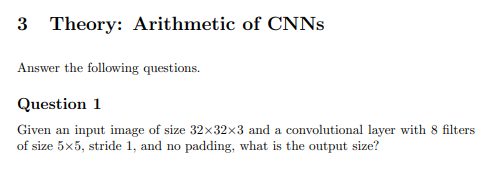

Based on the formula for calculating width and height:

$$
\frac{width + 2 \times padding - (kernel size - 1) - 1}{S} + 1
$$

Since the input image's height and width are both 32, kernel size is 5, stride is 1, padding is 0, we can calculate the output height and width as follows:

((32 + 2 * 0 - (5-1) -1) / 1) + 1 = 28

So the output height and width will both be 28. Since the number of filters is 8, the output channels will be 8.

So the output size will be 28 * 28 * 8

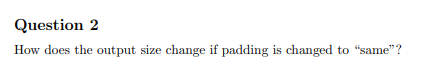

Since the padding is changed to "same", the output height and width will be the same as the input height and width, which is 32. The number of filters is still 8, so the output channels will be 8. So the output size will be 32 * 32 * 8

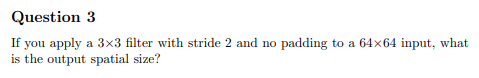

Base on the formula for calculating width and height:

$$
\frac{width + 2p - k}{S} + 1
$$

The input image's height and width are both 64, kernel size is 3, stride is 2, padding is 0, so the output height and width will be:

((64 + 2 * 0 - 3) / 2) + 1 = 31

Output spatial size will be 31 * 31

P.S. When calculating the output size, we need to take the floor of the result, so the output height and width will both be 31 instead of 31.5

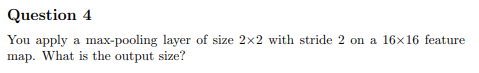

Since there is a max-pooling layer with kernel size 2 and stride 2, based on the formula for calculating width and height:

$$
\frac{width + 2p - k}{S} + 1
$$

kernel = 2, stride = 2, padding = 0, so the output height and width will be:

((16 + 2 * 0 - 2) / 2) + 1 = 8

So the output size will be 8 * 8

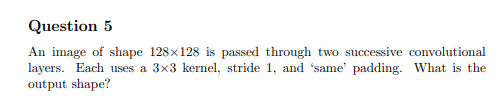

Since both convolutional layers use a 3×3 kernel, stride 1, and same padding, the spatial dimensions remain unchanged after each layer. Therefore, the output spatial shape is 128 × 128.

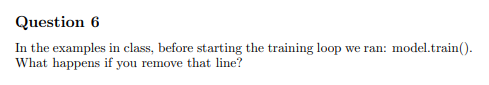

model.train() sets the model to training mode. If this line is removed, the model may remain in evaluation mode if model.eval() was called earlier. This affects layers such as Dropout and BatchNorm. Dropout will not randomly deactivate neurons, and BatchNorm will use stored running statistics instead of batch statistics. As a result, the model may train incorrectly or perform worse. If the model was newly created and never switched to eval mode, it is already in training mode by default, so removing the line may not immediately change the behavior, but it is still best practice to keep it.

In class code, model training part is ahead of model eval part, so if we run the code in order, the model will be in training mode when we call model.eval() later. However, if we want to retrain the model, run the train part again, the model may be in evaluation mode for sure, which can lead to unexpected behavior. The model can still compute gradients and update weights, but Dropout and BatchNorm will behave as if the model is in evaluation mode.